# RE buildout + battery storage vs. residual load

`world-of-energy`'s
[`54_germany_energy_battery_mix_costs`](https://quantitative-thinking.com/world-of-energy/notebooks/germany-energy-battery-mix-costs/)
runs a full cost-optimised dispatch (LCOE per technology, an LP-optimal
capacity mix, constant 1 MW demand). This page asks a narrower physical
question with this hub's simplest capacity-factor product
(`pecd_country_capacity_factors_simple`, the plain area/technology-mix
average used throughout this book, not MaStR-weighted): **if Germany scales
up today's wind+solar fleet by some factor, how much of real demand ends up
covered and how much surplus gets curtailed -- and once a battery is added
on top, how much of that curtailed surplus actually becomes useful, and
does it make Dunkelflauten go away?** No costs, no optimisation -- just a
buildout multiplier and (later) a battery size, against real hourly demand
rather than a constant or weekday-average assumption.

**Method, in one paragraph:** today's installed solar/onshore/offshore
capacity (`capacity_by_region_year`, latest snapshot) is scaled by a single
multiplier -- the technology *mix* is held fixed at today's ratio, only its
overall size changes. Hourly generation is capacity factor x scaled
capacity, compared hour by hour against SMARD's actual `total_load` (real
demand, not modeled). Section 1 looks at buildout alone, with no storage at
all, to build intuition for the underlying supply/demand mismatch. Section
2 then adds a single aggregate battery and asks specifically how much of
the surplus that buildout alone would otherwise waste, storage can
actually capture and deliver back.

**What this does *not* model:** transmission constraints, other
flexibility (demand response, hydro, interconnectors), or a
multi-technology battery/gas cost trade-off -- see `54` for that fuller,
cost-optimised picture.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from insights.paths import hub_file

DIRECT_COLOR = "#2a78d6"      # RE used directly
RESIDUAL_COLOR = "#a9a8a2"    # unmet demand -- gas/import
CURTAILED_COLOR = "#e34948"   # generated but wasted
DELIVERED_COLOR = "#1baf7a"   # RE delivered later via battery

# Battery scenarios are an *ordinal* series (increasing storage duration), so
# they get a single-hue sequential ramp rather than distinct categorical
# hues -- "no battery" in neutral gray, then light-to-dark blue with size.
BATTERY_COLORS = {
    "No battery": "#a9a8a2",
    "4h battery": "#9ec5f4",
    "24h battery": "#3987e5",
    "168h battery": "#0d366b",
}

DE_LU_CREATION_DATE = "2018-10-01"  # see 04's note: SMARD's DE-LU load/generation series is unreliable before this
MULTIPLIERS = [1.0, 1.5, 2.0, 2.5, 3.0, 4.0, 5.0, 6.0, 8.0]

## Data

DE capacity factors (`pecd_country_capacity_factors_simple`), real hourly
demand (`smard_load`), and today's installed capacity (`capacity_by_region_year`,
latest year-end snapshot), joined on their common hourly range.

In [2]:
cf = pd.read_parquet(hub_file("pecd", "pecd_country_capacity_factors_simple.parquet"))
de_cf = cf.xs("DE", axis=1, level="country")
load = pd.read_parquet(hub_file("smard", "load.parquet"))["total_load"]

panel = de_cf.join(load.rename("demand_mw"), how="inner").loc[DE_LU_CREATION_DATE:].dropna()
demand = panel["demand_mw"].values.astype(float)
avg_demand_mw = demand.mean()

TECHS = ["solar", "wind_onshore", "wind_offshore"]
cf_arrays = {tech: panel[tech].values.astype(float) for tech in TECHS}

print(f"Simulation period: {panel.index.min()} -> {panel.index.max()}  ({len(panel):,} hours)")
print(f"Average demand: {avg_demand_mw / 1000:.1f} GW")

Simulation period: 2018-10-01 00:00:00 -> 2025-12-31 22:00:00  (63,572 hours)
Average demand: 55.4 GW


In [3]:
capacity_annual = pd.read_parquet(hub_file("capacity", "capacity_by_region_year.parquet"))
is_offshore = capacity_annual["region_code"].str.startswith("DEZZ")
latest_year = capacity_annual["year"].max()
latest = capacity_annual[capacity_annual["year"] == latest_year]

CURRENT_CAPACITY_MW = {
    "solar": latest.loc[latest["technology"] == "solar", "capacity_mw"].sum(),
    "wind_onshore": latest.loc[(latest["technology"] == "wind") & ~is_offshore.reindex(latest.index, fill_value=False), "capacity_mw"].sum(),
    "wind_offshore": latest.loc[(latest["technology"] == "wind") & is_offshore.reindex(latest.index, fill_value=False), "capacity_mw"].sum(),
}
total_current_gw = sum(CURRENT_CAPACITY_MW.values()) / 1000

print(f"Current installed capacity ({latest_year} snapshot):")
for tech, mw in CURRENT_CAPACITY_MW.items():
    print(f"  {tech:15s}  {mw / 1000:6.1f} GW")
print(f"  {'total':15s}  {total_current_gw:6.1f} GW")


def re_generation(buildout_multiplier: float) -> np.ndarray:
    return sum(cf_arrays[t] * CURRENT_CAPACITY_MW[t] * buildout_multiplier for t in TECHS)

Current installed capacity (2026 snapshot):
  solar             111.5 GW
  wind_onshore       69.8 GW
  wind_offshore      10.9 GW
  total             192.1 GW


## 1. Buildout alone, no storage

With no battery, every hour splits cleanly in two: a **surplus** hour
(generation > demand) covers all of demand directly and wastes the rest as
curtailment; a **deficit** hour covers only part of demand from RE, and the
rest is residual load someone else has to supply. Four numbers per hour,
by construction:

- `direct use = min(generation, demand)`
- `curtailed = max(generation - demand, 0)`
- `residual load = max(demand - generation, 0)`
- always: `direct use + residual load = demand`, and `direct use + curtailed = generation`

Averaging these over the ~7-year record gives one row per buildout
scenario below.

In [4]:
baseline_rows = []
for multiplier in MULTIPLIERS:
    gen = re_generation(multiplier)
    direct = np.minimum(gen, demand)
    curtailed = np.maximum(gen - demand, 0.0)
    residual = np.maximum(demand - gen, 0.0)
    baseline_rows.append({
        "multiplier": multiplier,
        "avg_demand_gw": demand.mean() / 1000,
        "avg_generated_gw": gen.mean() / 1000,
        "avg_direct_use_gw": direct.mean() / 1000,
        "avg_curtailed_gw": curtailed.mean() / 1000,
        "avg_residual_gw": residual.mean() / 1000,
        "curtailed_pct_of_generated": curtailed.mean() / gen.mean(),
        "residual_pct_of_demand": residual.mean() / demand.mean(),
    })

baseline = pd.DataFrame(baseline_rows)
pd.set_option("display.float_format", lambda v: f"{v:.2f}")
print(baseline.to_string(index=False))

 multiplier  avg_demand_gw  avg_generated_gw  avg_direct_use_gw  avg_curtailed_gw  avg_residual_gw  curtailed_pct_of_generated  residual_pct_of_demand
       1.00          55.45             32.95              31.14              1.81            24.31                        0.06                    0.44
       1.50          55.45             49.43              39.51              9.92            15.94                        0.20                    0.29
       2.00          55.45             65.91              44.21             21.70            11.24                        0.33                    0.20
       2.50          55.45             82.38              47.15             35.23             8.30                        0.43                    0.15
       3.00          55.45             98.86              49.12             49.74             6.33                        0.50                    0.11
       4.00          55.45            131.81              51.51             80.31             

### The same table, as a picture

One stacked column per buildout multiplier. Below the dashed demand line:
direct RE use (blue) + residual load (gray) -- these two always sum to
demand exactly, so the stack top touches the line by construction. Above
the line: curtailed generation (red) -- energy produced but not usable
that hour, because there was already enough.

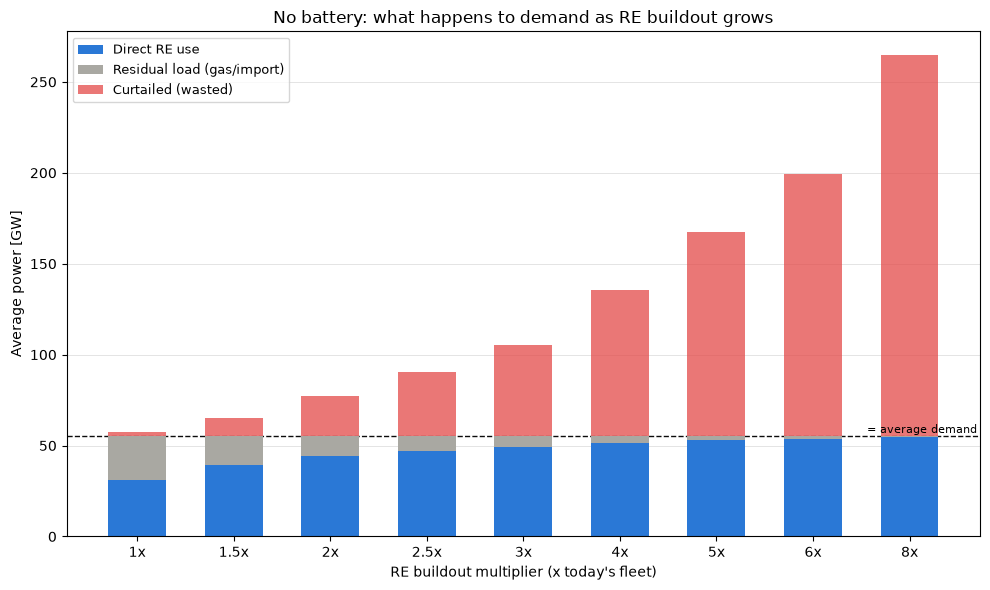

In [5]:
fig, ax = plt.subplots(figsize=(10, 6))
x = np.arange(len(MULTIPLIERS))
width = 0.6

ax.bar(x, baseline["avg_direct_use_gw"], width, color=DIRECT_COLOR, label="Direct RE use")
ax.bar(x, baseline["avg_residual_gw"], width, bottom=baseline["avg_direct_use_gw"], color=RESIDUAL_COLOR, label="Residual load (gas/import)")
ax.bar(x, baseline["avg_curtailed_gw"], width, bottom=baseline["avg_demand_gw"], color=CURTAILED_COLOR, alpha=0.75, label="Curtailed (wasted)")

ax.axhline(avg_demand_mw / 1000, color="#0b0b0b", linewidth=1, linestyle="--", zorder=0)
ax.text(len(MULTIPLIERS) - 0.3, avg_demand_mw / 1000, " = average demand", va="bottom", ha="right", fontsize=8)

ax.set_xticks(x)
ax.set_xticklabels([f"{m:g}x" for m in MULTIPLIERS])
ax.set_xlabel("RE buildout multiplier (x today's fleet)")
ax.set_ylabel("Average power [GW]")
ax.set_title("No battery: what happens to demand as RE buildout grows")
ax.yaxis.grid(True, linewidth=0.4, alpha=0.6)
ax.set_axisbelow(True)
ax.legend(fontsize=9, loc="upper left")
fig.tight_layout()
plt.show()

Today's fleet (1x) covers 56% of demand directly on average (31 GW of
55 GW) and wastes almost nothing (6% of what it generates). Doubling it
(2x) more than halves the residual gap (44%→20% of demand) -- but a third
of everything generated is now curtailed. By 8x, residual load is down to
a mere 2% of demand, but **79% of all generated RE is thrown away** --
exactly the "mega overproduce, then waste most of it" pattern the
introduction expected, laid out in GW rather than just percentages.

## 2. Adding a battery: how much of the waste becomes useful?

A single aggregate battery: surplus hours charge it (instead of curtailing
immediately); deficit hours discharge it (instead of leaving the gap as
residual load), up to its remaining energy headroom. Charge/discharge
losses are split equally via `sqrt(round-trip efficiency)`, matching `54`'s
battery model.

**Sizing, and why there's no power/C-rate limit here:** an earlier version
of this page gave every battery the same fixed *power* rating and only
varied how many hours it could sustain that power -- but checking the
data, that fixed power rating turned out to be the binding constraint in
most deficit hours, not the energy capacity being varied. That defeats the
point of a "how much *storage* helps" sweep. So this version drops the
power limit entirely and sizes each battery purely by energy capacity,
expressed the transparent way: **`N` hours of average national demand**,
with unlimited charge/discharge rate.

```
capacity [GWh] = N x average demand [GW]
```

This is a deliberately generous assumption for the battery side (real
batteries also have a finite power rating) -- so any Dunkelflaute-tail
result that still holds under it would hold even harder for a real,
power-limited battery.

In [6]:
BATTERY_ROUND_TRIP_EFFICIENCY = 0.90
EFF = np.sqrt(BATTERY_ROUND_TRIP_EFFICIENCY)

BATTERY_SCENARIOS = {"No battery": 0.0, "4h battery": 4.0, "24h battery": 24.0, "168h battery": 168.0}

print("Battery scenarios (unlimited power; energy capacity = N hours of average demand):")
for label, duration_h in BATTERY_SCENARIOS.items():
    cap_gwh = duration_h * avg_demand_mw / 1000
    print(f"  {label:14s}  {duration_h:5.0f} h of avg demand   {cap_gwh:9,.0f} GWh  ({cap_gwh / 1000:.2f} TWh)")


def simulate(buildout_multiplier: float, duration_h: float) -> dict[str, np.ndarray]:
    """Hourly (generation, direct, delivered, curtailed, residual) arrays for one scenario."""
    gen = re_generation(buildout_multiplier)
    cap_mwh = duration_h * avg_demand_mw

    n = len(gen)
    soc = 0.0
    residual = np.empty(n)
    curtailed = np.empty(n)
    delivered = np.empty(n)
    for i in range(n):
        net = gen[i] - demand[i]
        if net > 0:
            can_take = min(net, (cap_mwh - soc) / EFF) if cap_mwh > 0 else 0.0
            soc += can_take * EFF
            curtailed[i] = net - can_take
            residual[i] = 0.0
            delivered[i] = 0.0
        else:
            deficit = -net
            can_give = min(deficit / EFF, soc) if cap_mwh > 0 else 0.0
            soc -= can_give
            delivered[i] = can_give * EFF
            residual[i] = deficit - delivered[i]
            curtailed[i] = 0.0

    return {
        "gen": gen,
        "direct": np.minimum(gen, demand),
        "delivered": delivered,
        "curtailed": curtailed,
        "residual": residual,
    }

Battery scenarios (unlimited power; energy capacity = N hours of average demand):
  No battery          0 h of avg demand           0 GWh  (0.00 TWh)
  4h battery          4 h of avg demand         222 GWh  (0.22 TWh)
  24h battery        24 h of avg demand       1,331 GWh  (1.33 TWh)
  168h battery      168 h of avg demand       9,315 GWh  (9.32 TWh)


### Where the extra energy goes, at one buildout level (2x)

Same stacked picture as section 1, one column per battery size, holding
buildout fixed at 2x (the level where section 1 showed batteries have the
most surplus available to work with). Direct use never changes -- only
how the *rest* gets split between delivered-later (green), still curtailed
(red), and still-residual (gray).

Decomposition at 2x buildout (GW, averaged over ~7 years):
     battery  direct_gw  delivered_gw  curtailed_gw  residual_gw
  No battery      44.21          0.00         21.70        11.24
  4h battery      44.21          4.32         16.90         6.92
 24h battery      44.21          7.75         13.06         3.49
168h battery      44.21         10.38         10.13         0.86


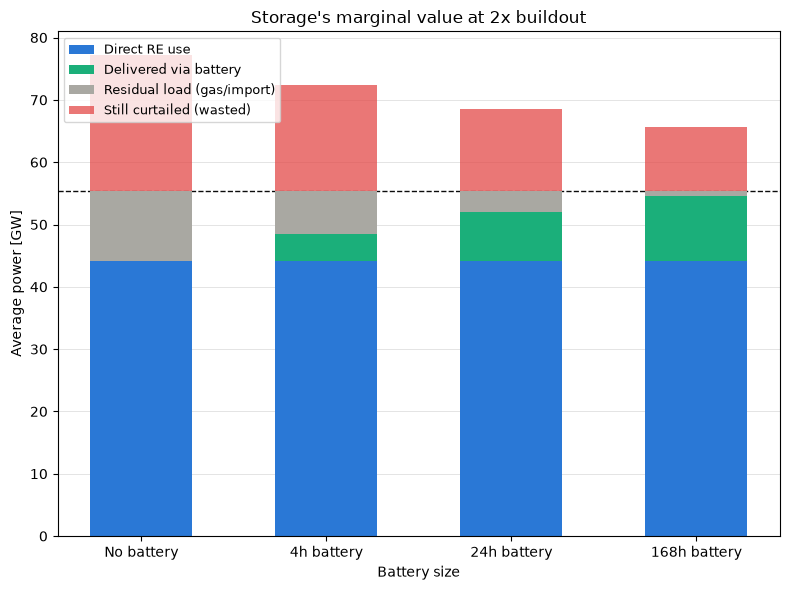

In [7]:
DEMO_MULTIPLIER = 2.0

decomposition_rows = []
for label, duration_h in BATTERY_SCENARIOS.items():
    r = simulate(DEMO_MULTIPLIER, duration_h)
    decomposition_rows.append({
        "battery": label,
        "direct_gw": r["direct"].mean() / 1000,
        "delivered_gw": r["delivered"].mean() / 1000,
        "curtailed_gw": r["curtailed"].mean() / 1000,
        "residual_gw": r["residual"].mean() / 1000,
    })
decomposition = pd.DataFrame(decomposition_rows)
print(f"Decomposition at {DEMO_MULTIPLIER:g}x buildout (GW, averaged over ~7 years):")
print(decomposition.to_string(index=False))

fig, ax = plt.subplots(figsize=(8, 6))
x = np.arange(len(decomposition))
width = 0.55

bottom = np.zeros(len(decomposition))
for col, color, label in [
    ("direct_gw", DIRECT_COLOR, "Direct RE use"),
    ("delivered_gw", DELIVERED_COLOR, "Delivered via battery"),
    ("residual_gw", RESIDUAL_COLOR, "Residual load (gas/import)"),
]:
    ax.bar(x, decomposition[col], width, bottom=bottom, color=color, label=label)
    bottom += decomposition[col].values
ax.bar(x, decomposition["curtailed_gw"], width, bottom=bottom, color=CURTAILED_COLOR, alpha=0.75, label="Still curtailed (wasted)")

ax.axhline(avg_demand_mw / 1000, color="#0b0b0b", linewidth=1, linestyle="--", zorder=0)
ax.set_xticks(x)
ax.set_xticklabels(decomposition["battery"])
ax.set_xlabel("Battery size")
ax.set_ylabel("Average power [GW]")
ax.set_title(f"Storage's marginal value at {DEMO_MULTIPLIER:g}x buildout")
ax.yaxis.grid(True, linewidth=0.4, alpha=0.6)
ax.set_axisbelow(True)
ax.legend(fontsize=9, loc="upper left")
fig.tight_layout()
plt.show()

At 2x buildout, the biggest battery tested (168h, 9.3 TWh -- about a
week's worth of *all of Germany's* average demand) still only delivers
~10 GW on average, cutting curtailment from 22 GW down to 10 GW and
residual load from 11 GW down to under 1 GW. It helps a lot, but it takes
an enormous reservoir to get there, and even that doesn't zero either one
out at this buildout level.

### Does storage's marginal value hold up across the whole buildout range?

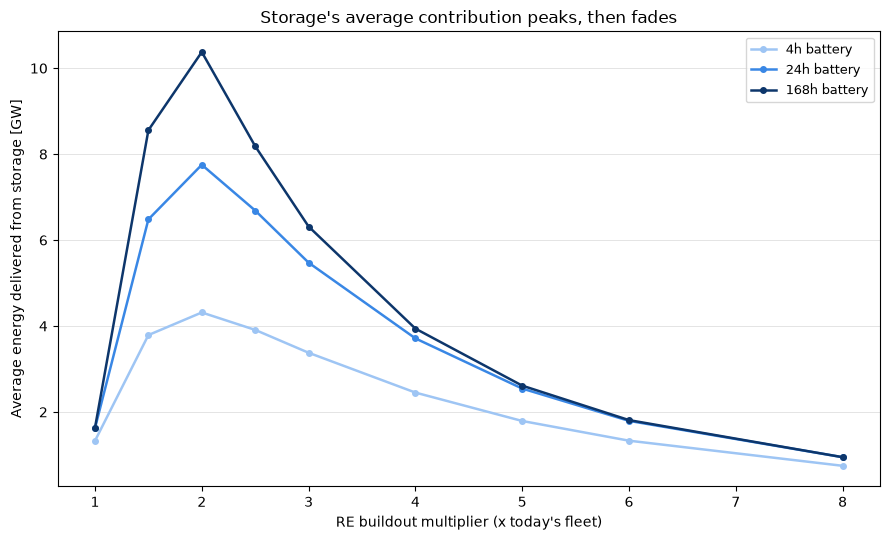

In [8]:
delivered_rows = []
for multiplier in MULTIPLIERS:
    row = {"multiplier": multiplier}
    for label, duration_h in BATTERY_SCENARIOS.items():
        if duration_h == 0:
            continue
        row[label] = simulate(multiplier, duration_h)["delivered"].mean() / 1000
    delivered_rows.append(row)
delivered_df = pd.DataFrame(delivered_rows)

fig, ax = plt.subplots(figsize=(9, 5.5))
for label in ["4h battery", "24h battery", "168h battery"]:
    ax.plot(delivered_df["multiplier"], delivered_df[label], marker="o", markersize=4,
            linewidth=1.8, color=BATTERY_COLORS[label], label=label)
ax.set_xlabel("RE buildout multiplier (x today's fleet)")
ax.set_ylabel("Average energy delivered from storage [GW]")
ax.set_title("Storage's average contribution peaks, then fades")
ax.yaxis.grid(True, linewidth=0.4, alpha=0.6)
ax.set_axisbelow(True)
ax.legend(fontsize=9, loc="upper right")
fig.tight_layout()
plt.show()

Every battery size follows the same hump: at low buildout there's little
surplus around to capture in the first place, so storage has little to
work with; at high buildout, residual load is already so small that
there's little left for storage to usefully fill. The 168h battery's
average contribution peaks around 2x buildout (~10 GW) and fades on both
sides -- a battery's usefulness is tied to *how imbalanced* generation and
demand are, not to its own size alone.

## Average renewable share and curtailment, with batteries

Same two-panel view as section 1, now split by battery scenario: average
RE + battery share of demand (`1 - average residual / average demand`),
and the share of *produced* RE that still ends up curtailed.

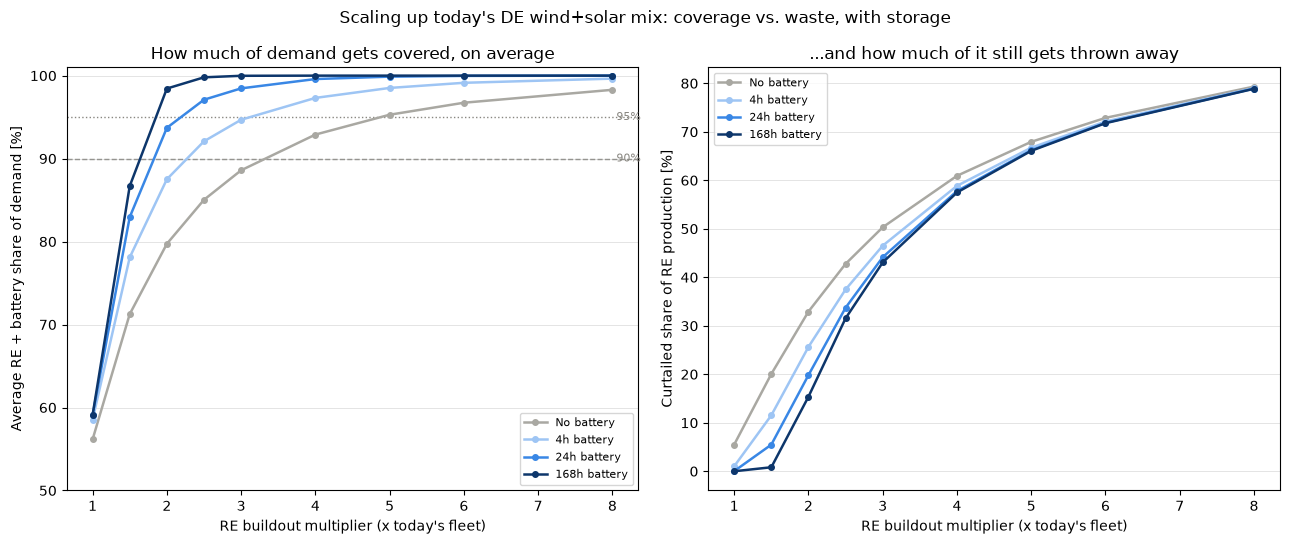

In [9]:
share_rows = []
for multiplier in MULTIPLIERS:
    for label, duration_h in BATTERY_SCENARIOS.items():
        r = simulate(multiplier, duration_h)
        share_rows.append({
            "multiplier": multiplier,
            "battery": label,
            "avg_re_share": 1 - r["residual"].mean() / avg_demand_mw,
            "curtailment_share": r["curtailed"].sum() / r["gen"].sum(),
            "peak_residual_frac": r["residual"].max() / avg_demand_mw,
            "battery_capacity_twh": duration_h * avg_demand_mw / 1e6,
        })
results = pd.DataFrame(share_rows)

fig, (ax_share, ax_curt) = plt.subplots(1, 2, figsize=(13, 5.5), sharex=True)
for label in BATTERY_SCENARIOS:
    sub = results[results["battery"] == label].sort_values("multiplier")
    ax_share.plot(sub["multiplier"], sub["avg_re_share"] * 100, marker="o", markersize=4,
                  linewidth=1.8, color=BATTERY_COLORS[label], label=label)
    ax_curt.plot(sub["multiplier"], sub["curtailment_share"] * 100, marker="o", markersize=4,
                 linewidth=1.8, color=BATTERY_COLORS[label], label=label)

for target, style in [(90, "--"), (95, ":")]:
    ax_share.axhline(target, color="#898781", linewidth=1, linestyle=style, zorder=0)
    ax_share.text(MULTIPLIERS[-1], target, f" {target}%", color="#898781", fontsize=8, va="center")

ax_share.set_ylabel("Average RE + battery share of demand [%]")
ax_share.set_xlabel("RE buildout multiplier (x today's fleet)")
ax_share.set_title("How much of demand gets covered, on average")
ax_share.set_ylim(50, 101)
ax_share.yaxis.grid(True, linewidth=0.4, alpha=0.6)
ax_share.set_axisbelow(True)
ax_share.legend(fontsize=8, loc="lower right")

ax_curt.set_ylabel("Curtailed share of RE production [%]")
ax_curt.set_xlabel("RE buildout multiplier (x today's fleet)")
ax_curt.set_title("...and how much of it still gets thrown away")
ax_curt.yaxis.grid(True, linewidth=0.4, alpha=0.6)
ax_curt.set_axisbelow(True)
ax_curt.legend(fontsize=8, loc="upper left")

fig.suptitle("Scaling up today's DE wind+solar mix: coverage vs. waste, with storage")
fig.tight_layout()
plt.show()

Batteries shift both curves outward -- less buildout (or less curtailment)
needed for the same average coverage -- but diminishing returns still set
in fast. For the 24h-battery line: going from 1x to 1.5x buildout buys
+24 percentage points of average share; 1.5x to 2x buys +11; 2x to 2.5x
only +3.4; 2.5x to 3x barely +1.4. With a 24h battery, ~94% average share
is already within reach at 2x buildout, and ~99% by 3x -- the no-battery
baseline needs 5x to even reach ~95%. Storage doesn't change the
diminishing-returns *shape*, but it moves the "comparatively cheap" 90-95%
band to a much more modest buildout level.

## Peak residual load: the backup capacity question

Average share covered is one question; **how big must standby backup
capacity be** is another. This plots the single worst hour's residual load
(as a fraction of *average* demand) per scenario -- i.e. what a gas fleet
(or import capacity) sized for "the worst hour in ~7 years" would need to
cover, regardless of how rarely that hour occurs.

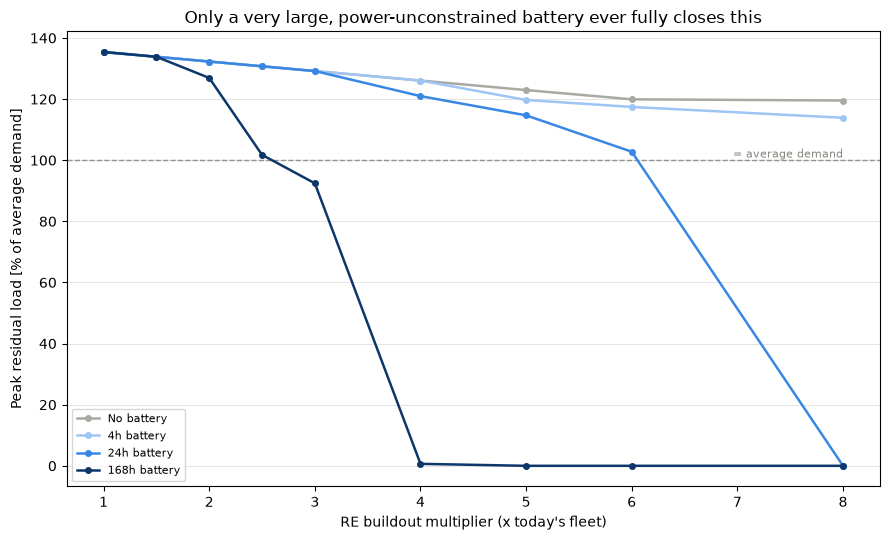

In [10]:
fig, ax = plt.subplots(figsize=(9, 5.5))
for label in BATTERY_SCENARIOS:
    sub = results[results["battery"] == label].sort_values("multiplier")
    ax.plot(sub["multiplier"], sub["peak_residual_frac"] * 100, marker="o", markersize=4,
            linewidth=1.8, color=BATTERY_COLORS[label], label=label)

ax.axhline(100, color="#898781", linewidth=1, linestyle="--", zorder=0)
ax.text(MULTIPLIERS[-1], 100, " = average demand", color="#898781", fontsize=8, va="bottom", ha="right")
ax.set_xlabel("RE buildout multiplier (x today's fleet)")
ax.set_ylabel("Peak residual load [% of average demand]")
ax.set_title("Only a very large, power-unconstrained battery ever fully closes this")
ax.yaxis.grid(True, linewidth=0.4, alpha=0.6)
ax.set_axisbelow(True)
ax.legend(fontsize=8, loc="lower left")
fig.tight_layout()
plt.show()

Each battery size eventually drives the peak to zero -- but only once
buildout is large enough, and "large enough" scales steeply with battery
size: the 168h/9.3 TWh reservoir gets there around 4x-5x buildout; the
24h/1.3 TWh battery needs ~8x; the 4h/0.2 TWh battery never gets there in
this range at all. **Read the 168h/24h lines as a generous upper bound,
not a realistic one** -- a 9.3 TWh, power-unconstrained battery is
nowhere close to anything deployable today. The 4h line is closer to a
real (if still huge) grid battery, and it barely moves.

## Does the worst multi-day shortfall ever go away?

Cumulative-balance drawdown (`54`'s "system drawdown" method): running sum
of curtailed-minus-residual energy, then the deepest peak-to-trough decline
-- the total energy a backup source would have had to supply across the
single worst sustained episode in ~7 years.

**Caveat visible in the chart itself:** at 1.0x-1.5x buildout the system is
in *chronic* deficit (RE rarely exceeds demand at all), so the "episode"
is effectively the whole multi-year record, not a discrete weather event --
those two points measure something different from the rest of the curve
and are shown for continuity, not as a comparable Dunkelflaute figure.

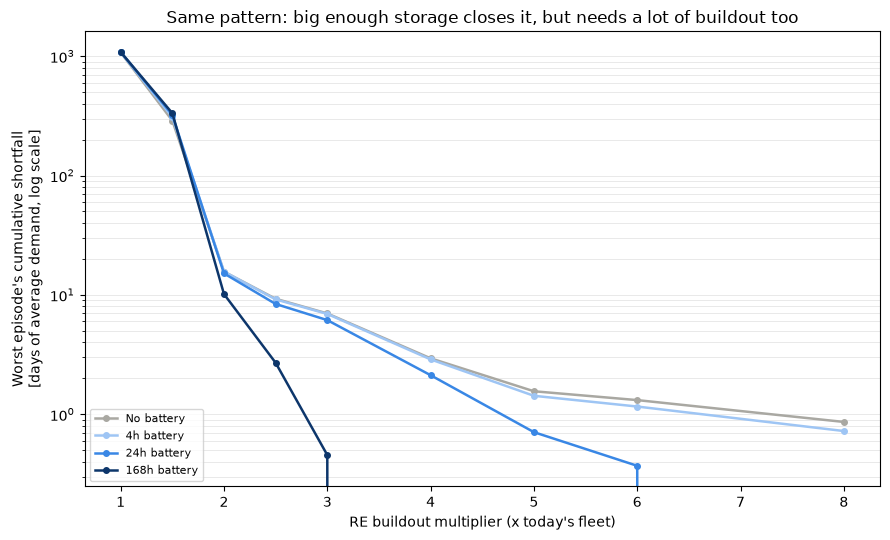

In [11]:
def worst_drawdown_days(curtailed: np.ndarray, residual: np.ndarray) -> float:
    balance = np.cumsum(curtailed - residual)
    running_max = np.maximum.accumulate(balance)
    trough_idx = int(np.argmin(balance - running_max))
    magnitude_mwh = running_max[trough_idx] - balance[trough_idx]
    return magnitude_mwh / avg_demand_mw / 24


drawdown_rows = []
for multiplier in MULTIPLIERS:
    row = {"multiplier": multiplier}
    for label, duration_h in BATTERY_SCENARIOS.items():
        r = simulate(multiplier, duration_h)
        row[label] = worst_drawdown_days(r["curtailed"], r["residual"])
    drawdown_rows.append(row)
drawdown_df = pd.DataFrame(drawdown_rows)

fig, ax = plt.subplots(figsize=(9, 5.5))
for label in BATTERY_SCENARIOS:
    ax.plot(drawdown_df["multiplier"], drawdown_df[label], marker="o", markersize=4,
            linewidth=1.8, color=BATTERY_COLORS[label], label=label)

ax.set_yscale("log")
ax.set_xlabel("RE buildout multiplier (x today's fleet)")
ax.set_ylabel("Worst episode's cumulative shortfall\n[days of average demand, log scale]")
ax.set_title("Same pattern: big enough storage closes it, but needs a lot of buildout too")
ax.yaxis.grid(True, which="both", linewidth=0.4, alpha=0.5)
ax.set_axisbelow(True)
ax.legend(fontsize=8, loc="lower left")
fig.tight_layout()
plt.show()

In [12]:
demand_day_twh = avg_demand_mw * 24 / 1e6
print("Worst episode, no battery vs. 168h battery (TWh), vs. that battery's own 9.3 TWh capacity:")
for multiplier in [1.0, 2.0, 3.0, 4.0]:
    no_bat = drawdown_df.loc[drawdown_df["multiplier"] == multiplier, "No battery"].iloc[0]
    big_bat = drawdown_df.loc[drawdown_df["multiplier"] == multiplier, "168h battery"].iloc[0]
    print(f"  {multiplier:.0f}x: {no_bat * demand_day_twh:6.1f} TWh (no battery)  ->  {big_bat * demand_day_twh:5.2f} TWh (168h battery)")

Worst episode, no battery vs. 168h battery (TWh), vs. that battery's own 9.3 TWh capacity:
  1x: 1429.9 TWh (no battery)  ->  1441.47 TWh (168h battery)
  2x:   20.8 TWh (no battery)  ->  13.52 TWh (168h battery)
  3x:    9.3 TWh (no battery)  ->   0.61 TWh (168h battery)
  4x:    3.9 TWh (no battery)  ->   0.00 TWh (168h battery)


At 2x buildout the underlying gap (20.8 TWh, no battery) is still more
than double the 168h battery's own 9.3 TWh capacity -- it can only chip
~7 TWh off, leaving 13.5 TWh unclosed. At 3x, the gap has shrunk to 9.3
TWh (no battery) -- almost exactly the battery's own size -- and it closes
all but 0.6 TWh of it. By 4x, the remaining gap (3.9 TWh, no battery) is
comfortably smaller than the battery, which duly drives it to zero. That
progression *is* the capacity-sufficiency story: a battery only closes a
gap once it's roughly as large as the gap itself. The smaller, more
realistic sizes (4h: 0.2 TWh, 24h: 1.3 TWh) never get there in this range
-- their capacity stays far below what even a moderately built-out
system's worst episode demands.

## A closer look at one near-ideal case

At 3x buildout with the 168h/9.3 TWh battery, average RE share is already
~100% and curtailment ~43% (see the two-panel chart above) -- about as
good as this lever combination gets in the tested range.

In [13]:
near_ideal = simulate(3.0, 168.0)
nonzero_hours = int((near_ideal["residual"] > 1e-6).sum())
total_hours = len(near_ideal["residual"])
print(f"Hours with any residual load at all: {nonzero_hours} of {total_hours:,} ({nonzero_hours / total_hours:.3%})")
print(f"Worst of those hours: {near_ideal['residual'].max() / 1000:.1f} GW "
      f"({near_ideal['residual'].max() / avg_demand_mw:.0%} of average demand)")

Hours with any residual load at all: 24 of 63,572 (0.038%)
Worst of those hours: 51.3 GW (92% of average demand)


Only 24 hours in ~7 years have *any* residual load at all under this
near-ideal setup -- and the worst of those 24 still needs ~51 GW, close to
average demand itself. That's the sharpest version of the point: even a
scenario that is, on paper, essentially fully renewable still needs a
backup fleet sized for near-total replacement, just used for a handful of
hours a decade instead of routinely.

## Residual-load duration curve, holding battery size fixed at 24h

Every hour's residual load, sorted descending, as a share of average
demand -- the shape a backup-fleet planner actually cares about, not just
the headline average. Buildout varies (1x/no-battery, 2x, 3x), battery
held at a constant, still-huge-but-not-absurd 24h/1.3 TWh, to isolate what
more buildout alone buys once storage is fixed.

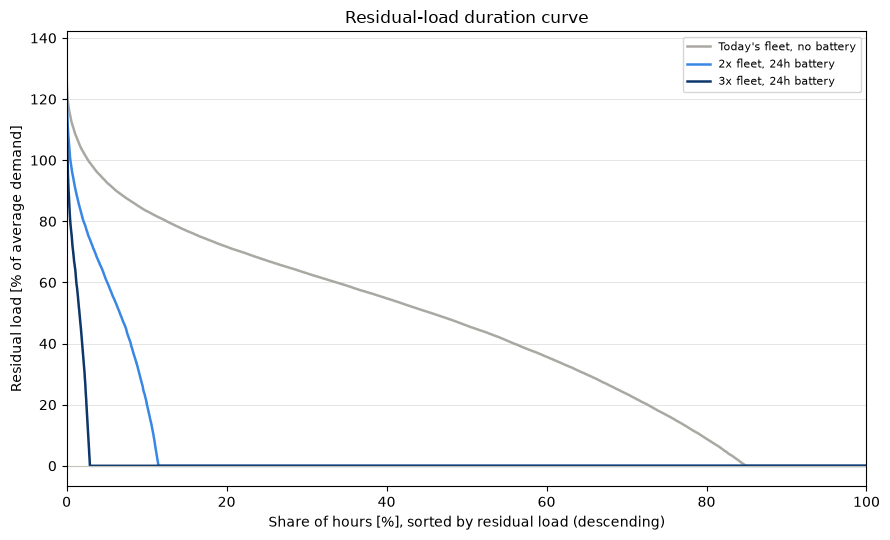

In [14]:
SCENARIOS_TO_TRACE = [
    ("Today's fleet, no battery", 1.0, "No battery"),
    ("2x fleet, 24h battery", 2.0, "24h battery"),
    ("3x fleet, 24h battery", 3.0, "24h battery"),
]
TRACE_COLORS = ["#a9a8a2", "#3987e5", "#0d366b"]

fig, ax = plt.subplots(figsize=(9, 5.5))
for (label, multiplier, battery_label), color in zip(SCENARIOS_TO_TRACE, TRACE_COLORS):
    duration_h = BATTERY_SCENARIOS[battery_label]
    r = simulate(multiplier, duration_h)
    sorted_residual = np.sort(r["residual"])[::-1] / avg_demand_mw * 100
    hours_pct = np.arange(1, len(sorted_residual) + 1) / len(sorted_residual) * 100
    ax.plot(hours_pct, sorted_residual, linewidth=1.8, color=color, label=label)

ax.set_xlabel("Share of hours [%], sorted by residual load (descending)")
ax.set_ylabel("Residual load [% of average demand]")
ax.set_title("Residual-load duration curve")
ax.set_xlim(0, 100)
ax.axhline(0, color="#c3c2b7", linewidth=0.8)
ax.yaxis.grid(True, linewidth=0.4, alpha=0.6)
ax.set_axisbelow(True)
ax.legend(fontsize=8, loc="upper right")
fig.tight_layout()
plt.show()

Going from 2x to 3x buildout (same 24h battery both times) shrinks the
share of hours with *any* residual load at all from 11.5% down to 2.9% --
a big win across most of the distribution. But the very top of the curve
barely moves: the single worst hour sits at 132% of average demand at 2x
and still 129% at 3x, and the worst 0.1% of hours is ~113% vs. ~102%.
Buildout keeps paying off across almost the whole distribution, long after
it's stopped moving the peak.

## Summary: four scenarios side by side

In [15]:
NAMED_SCENARIOS = [
    ("Today's fleet", 1.0, "No battery"),
    ("~94% avg RE, with 24h battery", 2.0, "24h battery"),
    ("~100% avg RE, with 168h battery", 3.0, "168h battery"),
    ("~95% avg RE, no battery at all", 5.0, "No battery"),
]

summary_rows = []
for label, multiplier, battery_label in NAMED_SCENARIOS:
    duration_h = BATTERY_SCENARIOS[battery_label]
    r = simulate(multiplier, duration_h)
    avg_re_share = 1 - r["residual"].mean() / avg_demand_mw
    curtailment_share = r["curtailed"].sum() / r["gen"].sum()
    peak_residual = r["residual"].max() / avg_demand_mw
    worst_episode = worst_drawdown_days(r["curtailed"], r["residual"])
    summary_rows.append({
        "scenario": label,
        "buildout": f"{multiplier:.1f}x ({multiplier * total_current_gw:,.0f} GW)",
        "battery": f"{battery_label} ({duration_h * avg_demand_mw / 1e6:.2f} TWh)" if duration_h else battery_label,
        "avg_re_share": f"{avg_re_share:.0%}",
        "curtailed": f"{curtailment_share:.0%}",
        "peak_residual": f"{peak_residual:.0%} of avg demand",
        "worst_episode": f"{worst_episode:.1f} demand-days",
    })

summary = pd.DataFrame(summary_rows).set_index("scenario")
print(summary.to_string())

                                      buildout                  battery avg_re_share curtailed       peak_residual       worst_episode
scenario                                                                                                                              
Today's fleet                    1.0x (192 GW)               No battery          56%        6%  135% of avg demand  1074.6 demand-days
~94% avg RE, with 24h battery    2.0x (384 GW)   24h battery (1.33 TWh)          94%       20%  132% of avg demand    15.1 demand-days
~100% avg RE, with 168h battery  3.0x (576 GW)  168h battery (9.32 TWh)         100%       43%   92% of avg demand     0.5 demand-days
~95% avg RE, no battery at all   5.0x (961 GW)               No battery          95%       68%  123% of avg demand     1.6 demand-days


## Takeaways

- **The first ~90-95% of average renewable share is comparatively cheap.**
  Roughly doubling today's wind+solar fleet, paired with a large-but-not-
  absurd (24h) battery, gets ~94% of demand covered on average with
  "only" ~20% curtailment of RE production.
- **A battery's marginal value has a sweet spot, not a straight line.** It
  peaks around 2x buildout (where there's both meaningful surplus to
  capture and meaningful deficit to fill) and fades at both extremes --
  sizing storage only makes sense relative to a given buildout level, not
  in isolation.
- **Only an unrealistically large, power-unconstrained battery ever fully
  closes the Dunkelflaute tail -- and even then, only once buildout is
  already very large.** The 168h/9.3 TWh scenario (about a week of the
  *entire country's* average demand, with no charge/discharge rate limit
  at all) eventually drives peak residual load and the worst multi-day
  shortfall to zero, but not before ~4x-5x buildout. Realistic sizes (4h,
  24h) never get there in the range tested here.
- **Even the best case studied still needs full backup capacity, just
  rarely.** At 3x buildout with the 168h battery, only 24 of ~63,500 hours
  have any residual load at all -- but the worst of those 24 still needs
  backup close to average demand. A 90-95% average share is a
  buildout/storage problem with a good cost-benefit ratio; the remaining
  sliver is a backup-*capacity* problem, still there even when the backup-
  *energy* problem has essentially been solved.